In [24]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display columns in dataframe
pd.set_option('display.max_columns', None)

# Data modeling
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# Saving models
import pickle

import os

In [25]:
df = pd.read_csv(r"C:\Users\amins\OneDrive\Desktop\HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [27]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [28]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [30]:
# Rename columns for consistent syntax
df = df.rename(columns={'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'})
# Confirm columns after update
df.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

In [31]:
# Check for null
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

In [32]:
# Check for duplicate
df.duplicated().sum()

3008

In [34]:
# Inspect duplicates
df[df.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [35]:
# Drop duplicates and save new df as df1
df1 = df.drop_duplicates(keep='first')

# Display new df1 variable
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


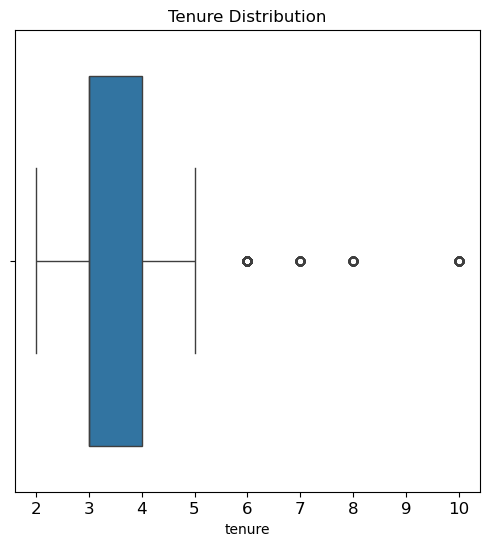

In [46]:
# Check for outliers
plt.figure(figsize=(6,6))
plt.title('Tenure Distribution', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.boxplot(x=df1['tenure'])
plt.show()

In [49]:
# Check number of rows with outliers
Q1 = df1["tenure"].quantile(0.25)
Q3 = df1["tenure"].quantile(0.75)

tenure_iqr = Q3 - Q1

tenure_upper_limit = Q3 + 1.5 * tenure_iqr
tenure_lower_limit = Q1 - 1.5 * tenure_iqr

tenure_outliers = df1[(df1["tenure"] > tenure_upper_limit) | (df1["tenure"] < tenure_lower_limit)]

print(f"Number of Rows With Outliers: {tenure_outliers.shape[0]}")

Number of Rows With Outliers: 824


In [50]:
# 25th percentile value in `tenure`
percentile25 = df1['tenure'].quantile(0.25)

# 75th percentile value in `tenure`
percentile75 = df1['tenure'].quantile(0.75)

# Interquartile range in `tenure`
iqr = percentile75 - percentile25

# Upper limit and lower limit for non-outliers in `tenure`
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Lower limit: 1.5
Upper limit: 5.5


In [51]:
# Number of people who left vs. stayed
print(df1['left'].value_counts())

# Percentage of people who left vs. stayed
print(df1['left'].value_counts(normalize=True))

left
0    10000
1     1991
Name: count, dtype: int64
left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


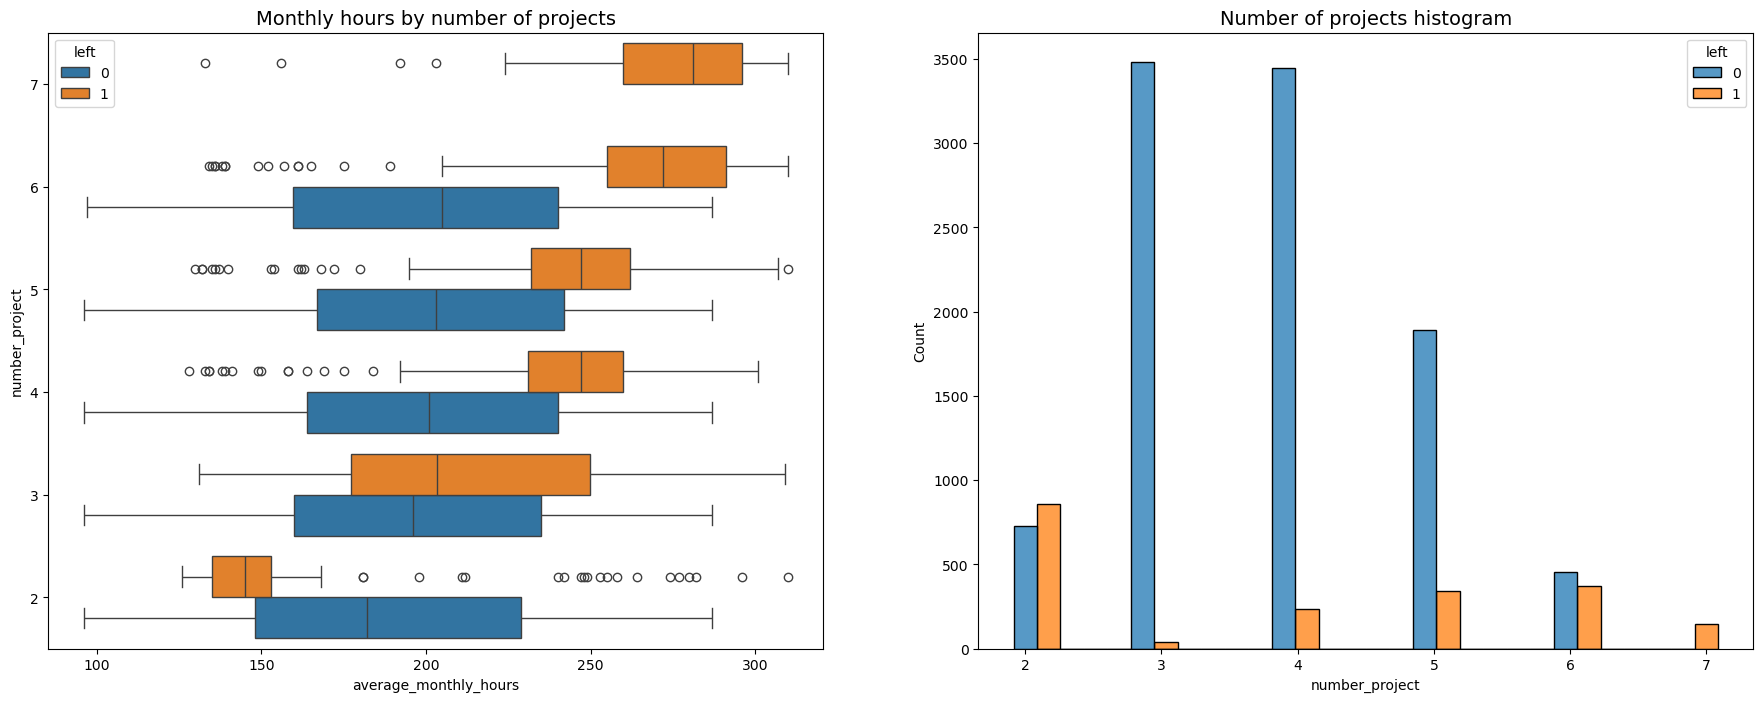

In [52]:
# Establish figure and axes
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Boxplot showing average_monthly_hours` distribution for `number_project` 
sns.boxplot(data=df1, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

# Create histogram showing distribution of `number_project`
tenure_stay = df1[df1['left']==0]['number_project']
tenure_left = df1[df1['left']==1]['number_project']
sns.histplot(data=df1, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')

# Both distributions compare those who stayed vs those who left

plt.show()

In [53]:
# Number of employees who stayed and those who left after 7 projects
df1[df1['number_project']==7]['left'].value_counts()

left
1    145
Name: count, dtype: int64

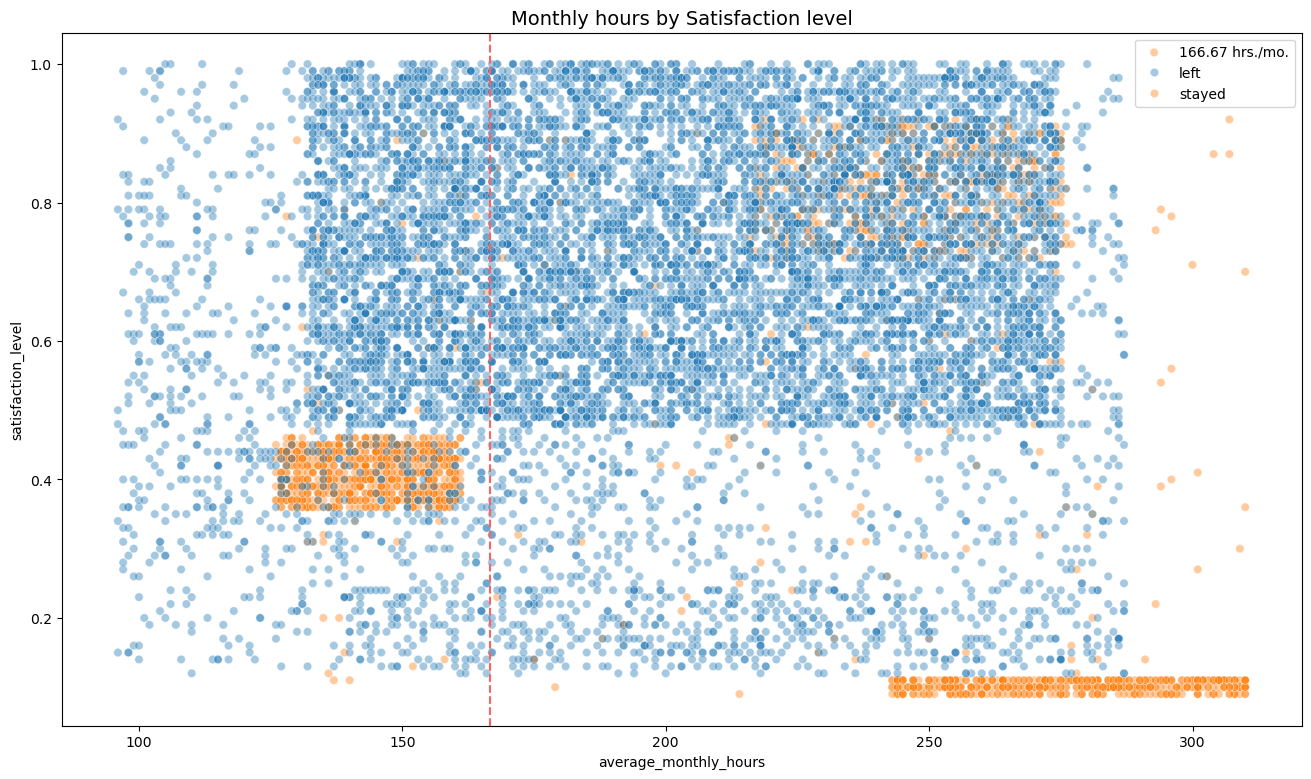

In [54]:
# Create scatterplot modeling average hours and employee satisfaction for any correlation
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by Satisfaction level', fontsize='14');

# This graph is also for people that stayed compared to those that left

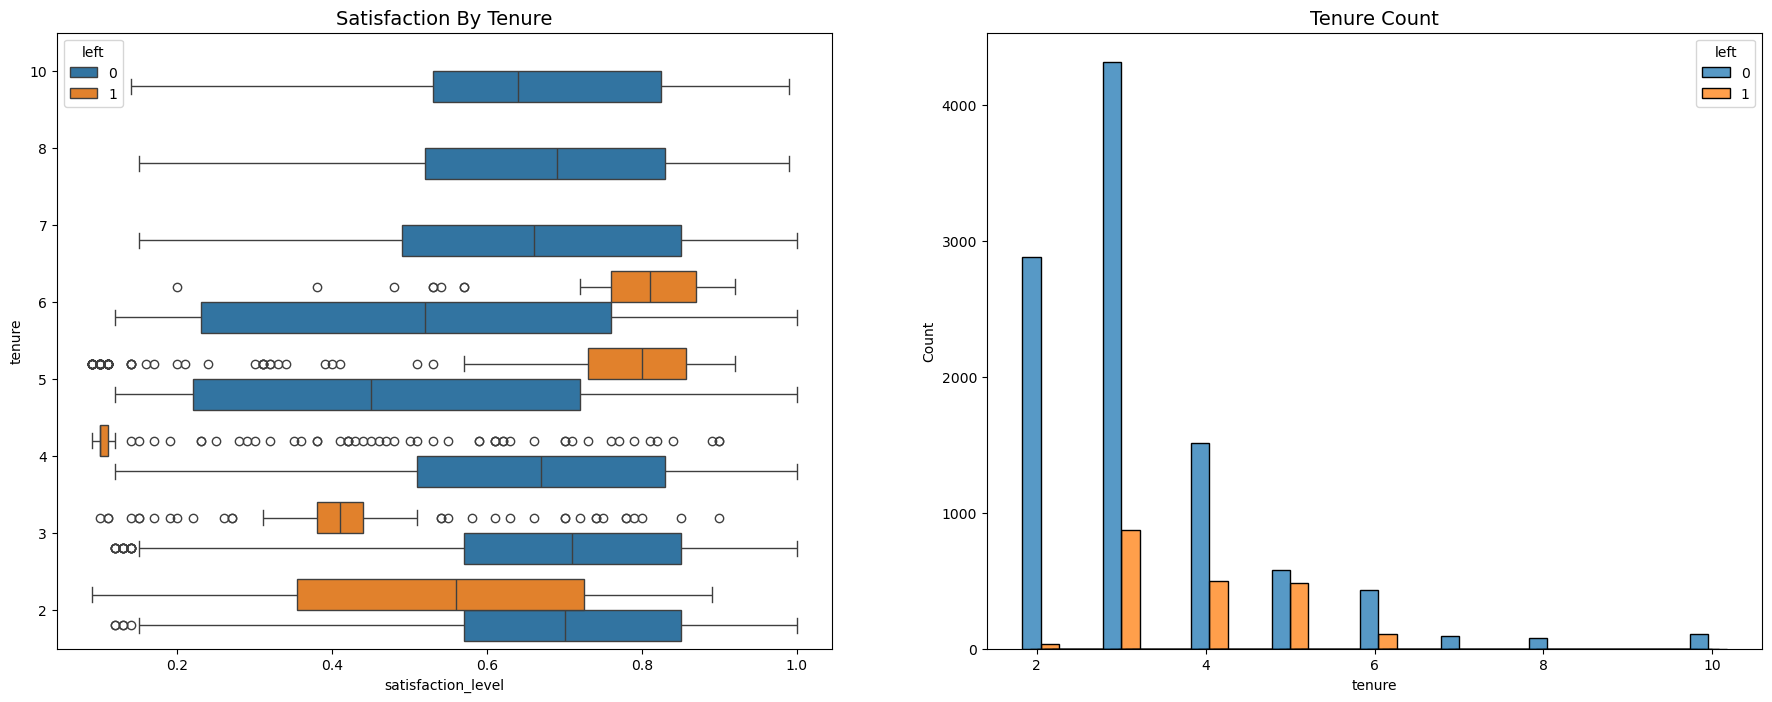

In [57]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Create boxplot modeling distribution of "satisfaction_level" by tenure
sns.boxplot(data=df1, x='satisfaction_level', y='tenure', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction By Tenure', fontsize='14')

# Create histogram showing distribution of tenure
tenure_stay = df1[df1['left']==0]['tenure']
tenure_left = df1[df1['left']==1]['tenure']
sns.histplot(data=df1, x='tenure', hue='left', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Tenure Count', fontsize='14')

# Both graphs compare employees who stayed and those who left

plt.show();

In [58]:
df1[df1["left"]==1]

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
1995,0.37,0.57,2,147,3,0,1,0,sales,low
1996,0.11,0.92,7,293,4,0,1,0,sales,low
1997,0.41,0.53,2,157,3,0,1,0,sales,low
1998,0.84,0.96,4,247,5,0,1,0,sales,low


Text(0.5, 1.0, 'Tenure Employee Salary: Left')

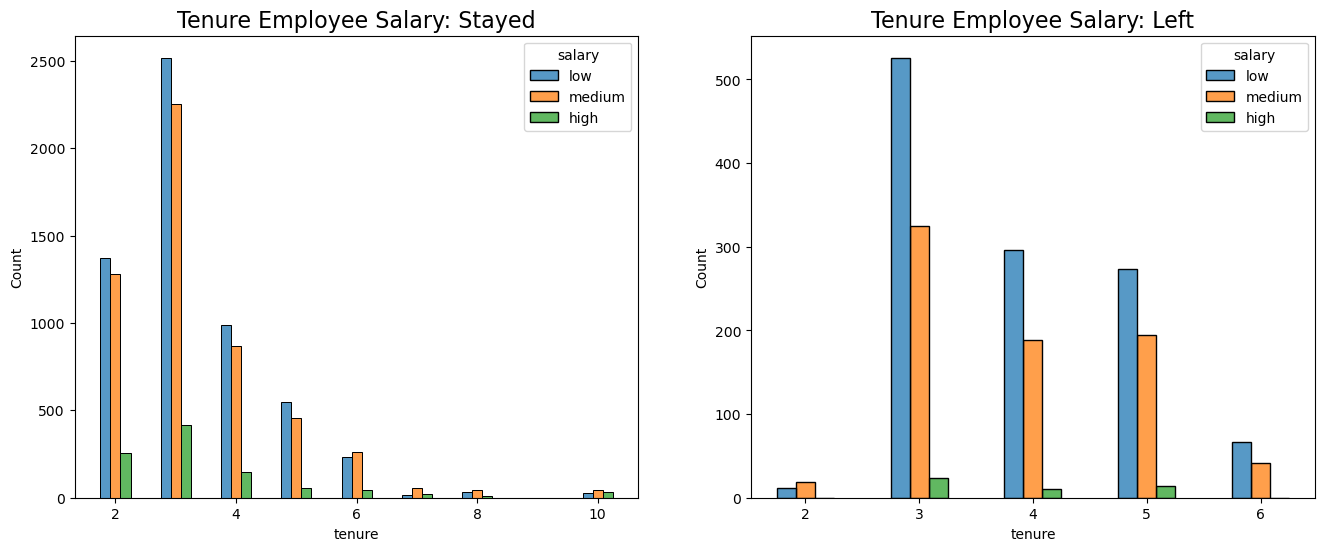

In [61]:
# Create distribution of employees by tenure and salary for employees who stayed vs left
fig, ax = plt.subplots(1, 2, figsize = (16,6))
 
sns.histplot(data=df1, x="tenure", hue="salary", discrete=1, 
             hue_order=["low", "medium", "high"], multiple="dodge", shrink=.5, ax=ax[0])

ax[0].set_title("Tenure Employee Salary: Stayed", fontsize=16)

 
df1_left = df1[df1["left"]==1]
sns.histplot(data=df1_left, x="tenure", hue="salary", discrete=1, 
             hue_order=["low", "medium", "high"], multiple="dodge", shrink=.5, ax=ax[1])

ax[1].set_title("Tenure Employee Salary: Left", fontsize=16)

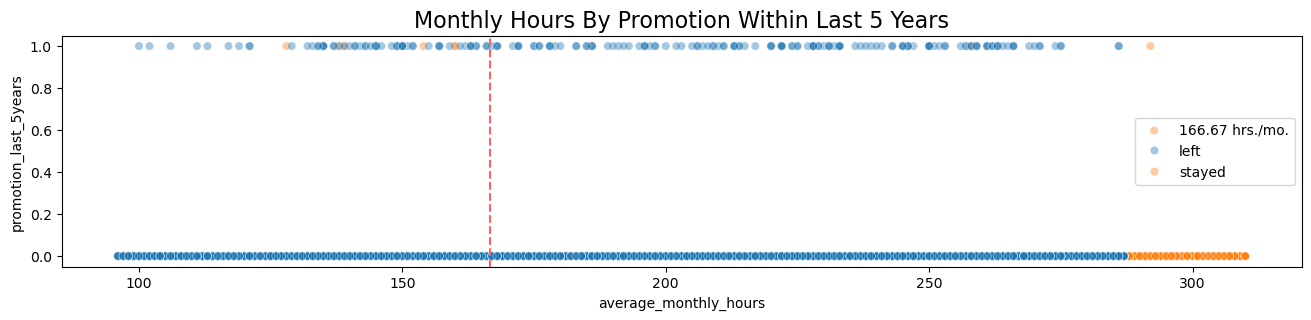

In [63]:
# Model relationship between `average_monthly_hours` and `promotion_last_5years`
plt.figure(figsize=(16, 3))
sns.scatterplot(data=df1, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly Hours By Promotion Within Last 5 Years', fontsize='16');

In [64]:
# Haven't checked by department, so checking for relationship within department
df1["department"].value_counts()

department
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

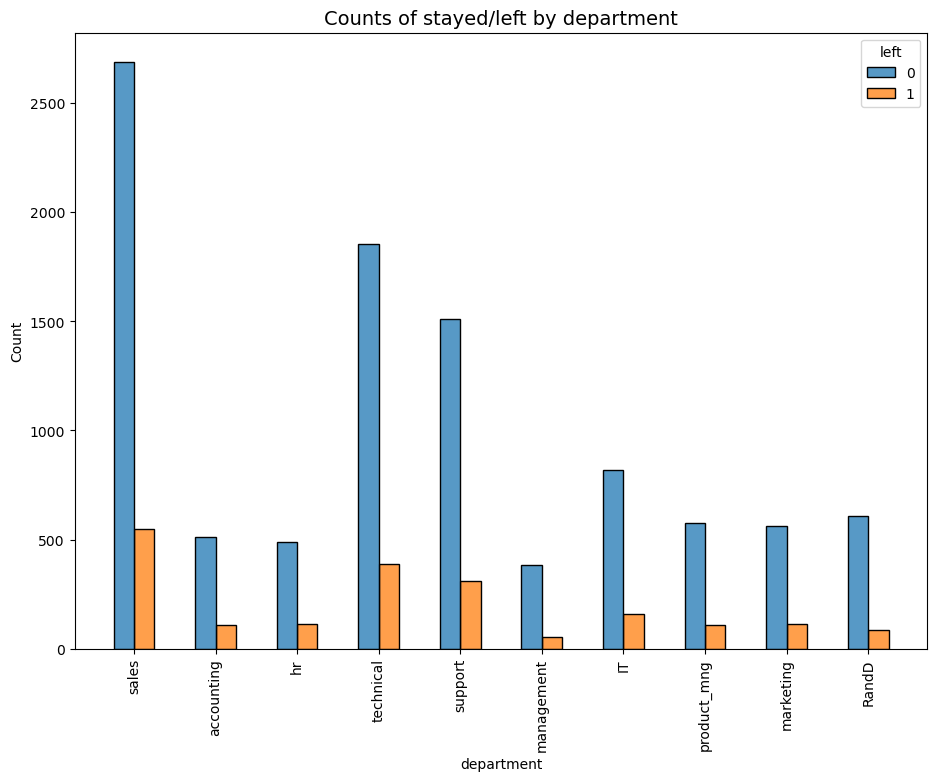

In [72]:
# Create stacked bar chart to compare department distribution of employees who stayed vs left
plt.figure(figsize=(11,8))
sns.histplot(data=df1, x='department', hue='left', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation=90)
plt.title('Counts of stayed/left by department', fontsize=14);

Text(0.5, 1.0, 'Correlation Heatmap')

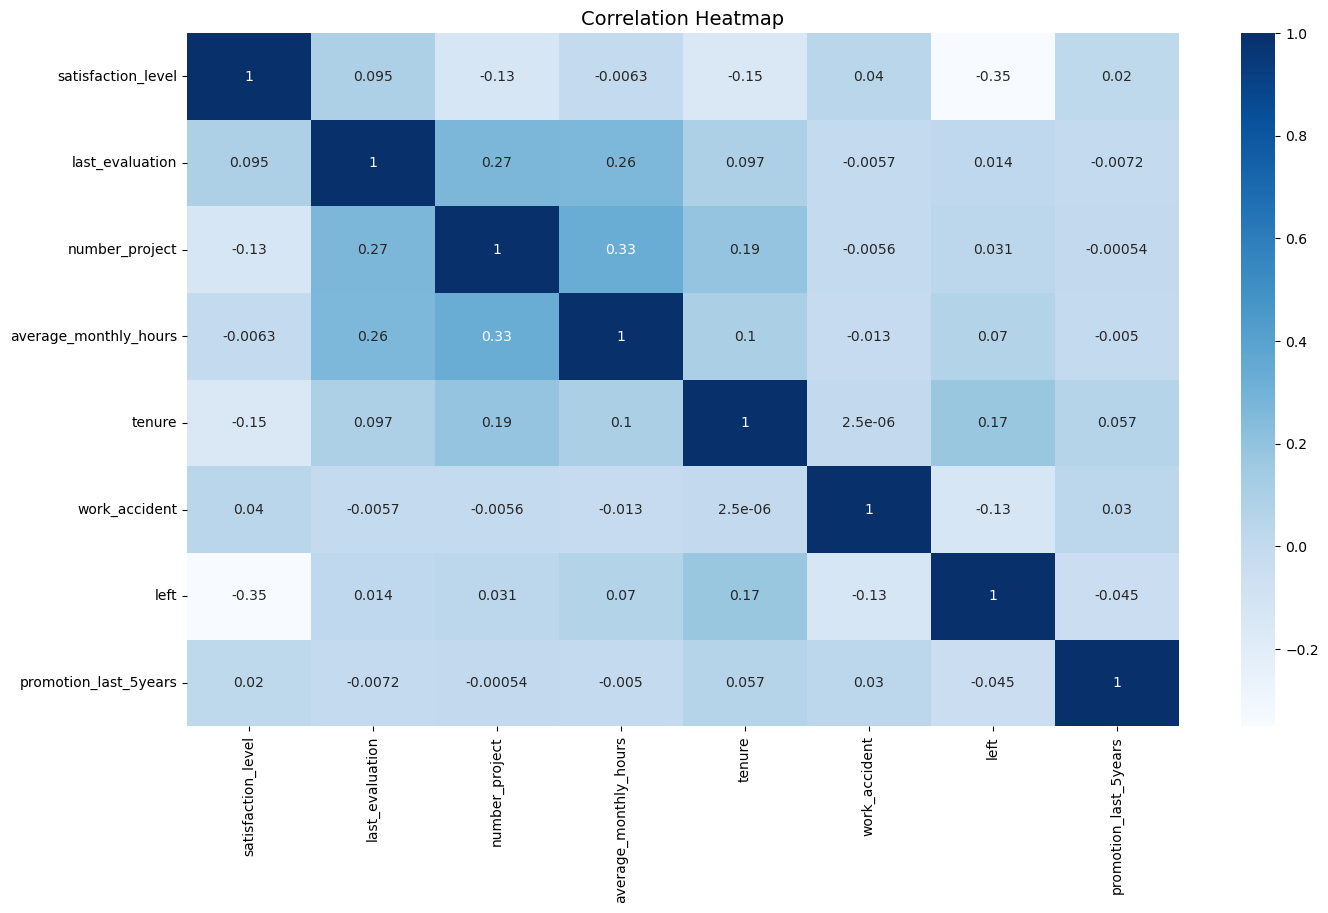

In [70]:
# Plot a correlation heatmap
plt.figure(figsize=(16, 9))
sns.heatmap(corr_df.corr(), cmap='Blues', annot=True)
plt.title("Correlation Heatmap", fontsize=14)


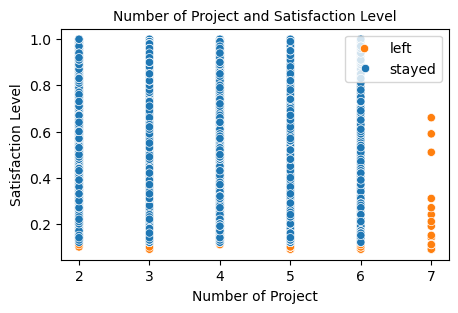

In [73]:
# Model number of projects and satisfation level
plt.figure(figsize=(5, 3))
sns.scatterplot(data = df1, x = "number_project", y = "satisfaction_level", hue = "left")
plt.xlabel("Number of Project")
plt.ylabel("Satisfaction Level")
plt.title("Number of Project and Satisfaction Level", fontsize=10)
plt.legend(labels=["left", "stayed"])
plt.show()

In [74]:
# Create copy
df1_enc = df1.copy()

# Encode "salary" as ordinal numeric category
df1_enc['salary'] = (
    df1_enc['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes)

# Dummy encode "department" column
df1_enc = pd.get_dummies(df1_enc, drop_first=False)

df1_enc.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


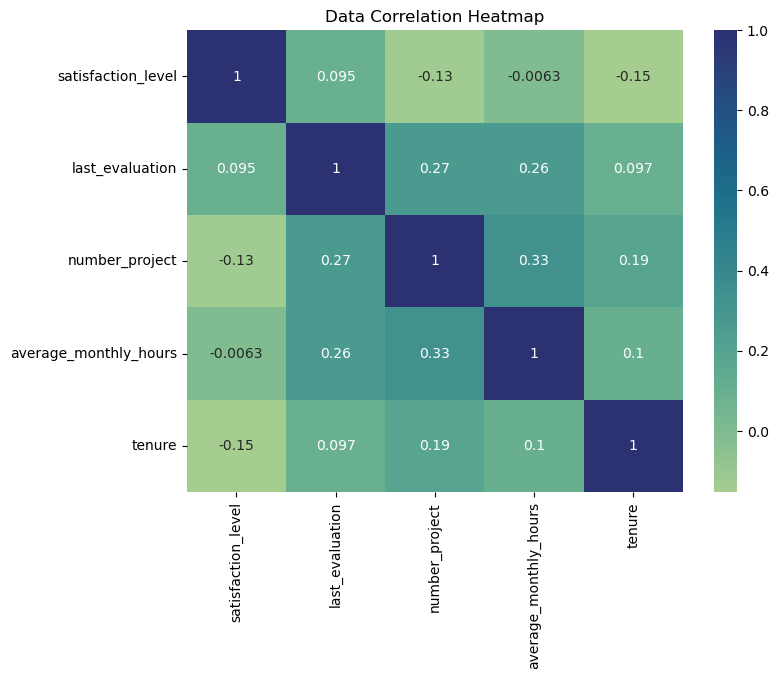

In [84]:
plt.figure(figsize=(8, 6))
sns.heatmap(df1_enc[['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure']]
            .corr(), annot=True, cmap="crest")
plt.title('Data Correlation Heatmap')
plt.show()

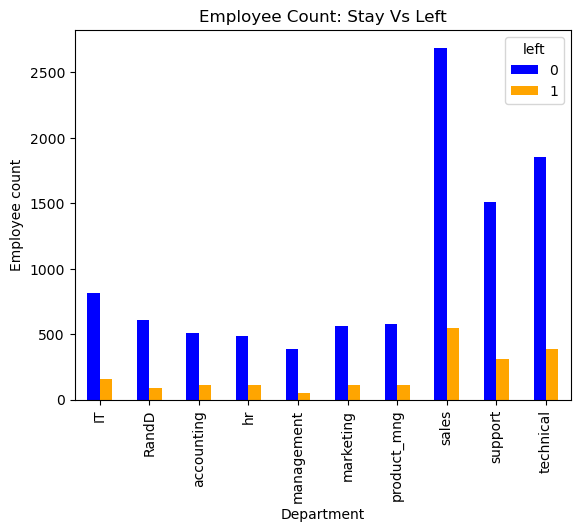

In [90]:
# Model employees who stayed vs left by department
pd.crosstab(df1['department'], df1['left']).plot(kind ='bar',color=['blue', 'orange'])
# Blue represents those who stayed and orange represents those who left
plt.title('Employee Count: Stay Vs Left')
plt.ylabel('Employee count')
plt.xlabel('Department')
plt.show()

In [93]:
# Select rows without outliers in `tenure` and save df as new variable
df_lr = df1_enc[(df1_enc['tenure'] >= lower_limit) & (df1_enc['tenure'] <= upper_limit)]

df_lr.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


In [94]:
# Isolate and display outcome variable
y = df_lr['left']
y.head() 

0    1
2    1
3    1
4    1
5    1
Name: left, dtype: int64

In [95]:
# Select and display the features you want to use in your model
X = df_lr.drop('left', axis=1) 
X.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,0,0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,0,0,False,False,False,False,False,False,False,True,False,False


In [96]:
# Split the data into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

In [97]:
# Construct a logistic regression model and fit to training set
log_clf = LogisticRegression(random_state=42, max_iter=500).fit(X_train, y_train)

In [98]:
# Use the logistic regression model to get predictions on the test set
y_pred = log_clf.predict(X_test)

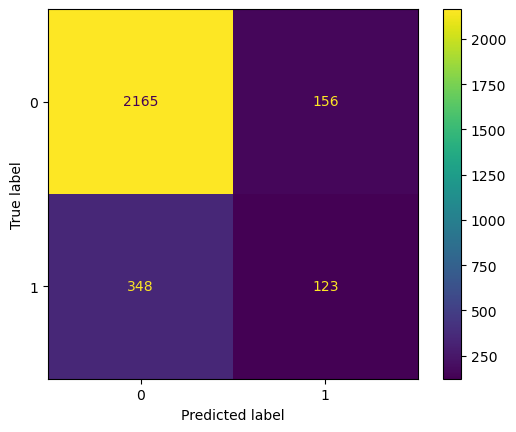

In [99]:
# Compute values for confusion matrix
log_cm = confusion_matrix(y_test, y_pred, labels=log_clf.classes_)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, 
                                  display_labels=log_clf.classes_)

# Plot confusion matrix- to visualize lr model
log_disp.plot(values_format='')

plt.show()

In [101]:
# Check class balance in data
df_lr['left'].value_counts(normalize=True)

left
0    0.831468
1    0.168532
Name: proportion, dtype: float64

In [103]:
# Create classification report for logistic regression model
target_names = ['Predicted would stay', 'Predicted would leave']
print(classification_report(y_test, y_pred, target_names=target_names))

                       precision    recall  f1-score   support

 Predicted would stay       0.86      0.93      0.90      2321
Predicted would leave       0.44      0.26      0.33       471

             accuracy                           0.82      2792
            macro avg       0.65      0.60      0.61      2792
         weighted avg       0.79      0.82      0.80      2792

